# Project Vision & Direction

### What This Is

The concept is a **personality quiz with meme-style results** — instead of showing dry psychological trait scores, users get fun relatable personality labels like _"Dare to Dream"_ or _"Frequently Forgets Items"_.

The quiz is powered by the **IPIP Big Five personality dataset** from Kaggle (~1M responses). The Big Five model measures five core personality dimensions — Extraversion, Agreeableness, Conscientiousness, Neuroticism, and Openness — each assessed by 10 questions on a 1–5 Likert scale (50 questions total).

### The Core UX Idea

- Users **can quit the quiz at any time** — even after just a few questions — and still get a result
- The more questions they answer, the more precise the result becomes
- There is a **soft limit at 30 questions** — at this point, users are prompted to see their result or keep going (it's just a "good enough" checkpoint, not an unlock gate)
- The result page **always shows all 50 personality items** — the 7 meme ones as the headline, the other 43 as secondary detail. Whatever the user hasn't answered yet is filled in by the model.
- **Question order is randomized** every session so repeat users get a fresh experience
- A **precision bar** is shown live so users can see their result getting more accurate as they answer

### Personality Output Design

The result page always shows **all 50 personality items**, split into two visual tiers — both shown regardless of how many questions the user has answered:

**Primary — 7 Core Meme Personalities** (the headline)
The branded meme personalities defined by the developer. These get the biggest UI treatment and are the *main thing* the user came for. Each maps to thresholds on a specific Big Five item (e.g. high `CSN6` → "Frequently Forgets Items").

**Secondary — 43 Other Items** (supporting detail)
The remaining 43 questions, displayed less prominently as "more about you". They give users extra flavor and reward those who answer more.

For any K answered between ~5 and 50: the K already-answered items are shown as known, the remaining `50 − K` are shown as **model predictions**. So a user who answered 13 sees `7 meme + ~30 secondary` predictions plus their 13 known answers; a user who answered 5 sees `7 meme + ~38 secondary` predictions plus their 5 knowns. Same UI, just less guessing the more they answer.

### The main 7

CSN6    I often forget to put things back in their proper place.

AGR9    I feel others' emotions.

AGR5    I am not interested in other people's problems.

EXT4    I keep in the background.

EST7    I change my mood a lot.

OPN3    I have a vivid imagination.

OPN10   I am full of ideas.


### 50 Question

EXT1	I am the life of the party.

EXT2	I don't talk a lot.

EXT3	I feel comfortable around people.

EXT4	I keep in the background.

EXT5	I start conversations.

EXT6	I have little to say.

EXT7	I talk to a lot of different people at parties.

EXT8	I don't like to draw attention to myself.

EXT9	I don't mind being the center of attention.

EXT10	I am quiet around strangers.

EST1	I get stressed out easily.

EST2	I am relaxed most of the time.

EST3	I worry about things.

EST4	I seldom feel blue.

EST5	I am easily disturbed.

EST6	I get upset easily.

EST7	I change my mood a lot.

EST8	I have frequent mood swings.

EST9	I get irritated easily.

EST10	I often feel blue.

AGR1	I feel little concern for others.

AGR2	I am interested in people.

AGR3	I insult people.

AGR4	I sympathize with others' feelings.

AGR5	I am not interested in other people's problems.

AGR6	I have a soft heart.

AGR7	I am not really interested in others.

AGR8	I take time out for others.

AGR9	I feel others' emotions.

AGR10	I make people feel at ease.

CSN1	I am always prepared.

CSN2	I leave my belongings around.

CSN3	I pay attention to details.

CSN4	I make a mess of things.

CSN5	I get chores done right away.

CSN6	I often forget to put things back in their proper place.

CSN7	I like order.

CSN8	I shirk my duties.

CSN9	I follow a schedule.

CSN10	I am exacting in my work.

OPN1	I have a rich vocabulary.

OPN2	I have difficulty understanding abstract ideas.

OPN3	I have a vivid imagination.

OPN4	I am not interested in abstract ideas.

OPN5	I have excellent ideas.

OPN6	I do not have a good imagination.

OPN7	I am quick to understand things.

OPN8	I use difficult words.

OPN9	I spend time reflecting on things.

OPN10	I am full of ideas.

# Set up

In [1]:
# the global library that freq use everywhere
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
import kagglehub
from pathlib import Path
import shutil

c:\Users\BTCOM\Desktop\1_Uni\B5Personality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Desired project-local dataset directory
target_dir = Path("./data/big-five-personality-test")
target_dir.mkdir(parents=True, exist_ok=True)

if any(target_dir.iterdir()):
    print(f"Dataset already exists at: {target_dir.resolve()}")
else:
    cache_path = Path(kagglehub.dataset_download("tunguz/big-five-personality-test"))
    print(f"Downloaded dataset cache to: {cache_path}")

    # Copy dataset files from KaggleHub cache into project data directory
    for item in cache_path.iterdir():
        dest = target_dir / item.name
        if item.is_dir():
            shutil.copytree(item, dest, dirs_exist_ok=True)
        else:
            shutil.copy2(item, dest)

    print(f"Dataset saved to: {target_dir.resolve()}")

Dataset already exists at: C:\Users\BTCOM\Desktop\1_Uni\B5Personality\models\data\big-five-personality-test


In [4]:
# Find the csv path from kagglehub download
csv_candidates = list(target_dir.rglob("data-final.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"Could not find data-final.csv under {target_dir.resolve()}")

csv_path = csv_candidates[0]
print(f"Loading dataset from: {csv_path}")

# Detect delimiter from header row (this dataset is TSV)
with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
    header_line = f.readline()

# Replace \t with ,
delimiter = "\t" if header_line.count("\t") > header_line.count(",") else ","
print(f"Detected delimiter: {repr(delimiter)}")

# Import to variable
df = pd.read_csv(csv_path, sep=delimiter)
df.head()

Loading dataset from: data\big-five-personality-test\IPIP-FFM-data-8Nov2018\data-final.csv
Detected delimiter: '\t'


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


# Data Exploring

### Understand the dataset

In [5]:
# Check entries
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), str(4)
memory usage: 885.3 MB


In [6]:
# Visual Properties feature
# First 50 column is 5 types of question, 10 question each
# First 50 column is usage of each equation

df.columns[100:]

Index(['dateload', 'screenw', 'screenh', 'introelapse', 'testelapse',
       'endelapse', 'IPC', 'country', 'lat_appx_lots_of_err',
       'long_appx_lots_of_err'],
      dtype='str')

In [7]:
df['country'].unique()

<ArrowStringArray>
['GB', 'MY', 'KE', 'SE', 'US', 'FI', 'UA', 'PH', 'FR', 'AU',
 ...
 'TL', 'GQ', 'TD', 'MF', 'PM', 'NE', 'DJ', 'GN', 'AS', 'SH']
Length: 224, dtype: str

### Summary
I think that the useful feature is just in first 100 featues that is 50 of question and another 50 of time for each qustion. 

And I think I will use only 50 of question too, cause I think the environment of cadidate users from my website and other research will be different, making time shift effect that so critical for prediction.

### Visual Correlation

### Extra Feature Check

#### Extra Feature

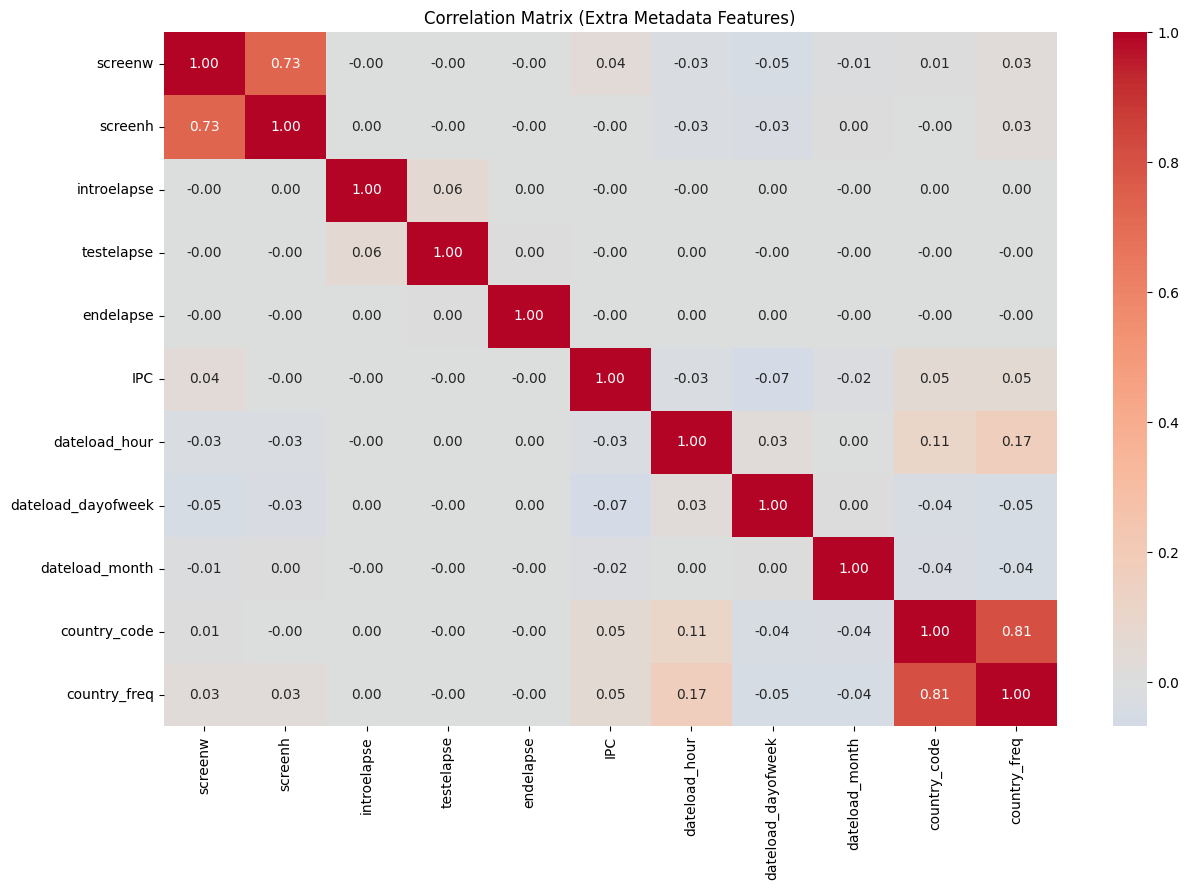

In [8]:
# CM-0001
# Correlation Matrix for extra metadata features

extra_cols = [
    "dateload",
    "screenw",
    "screenh",
    "introelapse",
    "testelapse",
    "endelapse",
    "IPC",
    "country",
    "lat_appx_lots_of_err",
    "long_appx_lots_of_err",
]

extra_cols = extra_cols

extra_df = df[extra_cols].copy()

# Convert timestamp into numeric time features
extra_df["dateload"] = pd.to_datetime(extra_df["dateload"], errors="coerce")
extra_df["dateload_hour"] = extra_df["dateload"].dt.hour
extra_df["dateload_dayofweek"] = extra_df["dateload"].dt.dayofweek
extra_df["dateload_month"] = extra_df["dateload"].dt.month
extra_df = extra_df.drop(columns=["dateload"])

# Convert country to numeric proxies for correlation plotting
extra_df["country_code"] = extra_df["country"].astype("category").cat.codes
country_freq = extra_df["country"].value_counts(normalize=True)
extra_df["country_freq"] = extra_df["country"].map(country_freq)
extra_df = extra_df.drop(columns=["country"])

corr = extra_df.corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Extra Metadata Features)")
plt.tight_layout()
plt.show()

#### Summary
`scrrenh` and `screenw` is diefitenitely relate each other cause the screen device, no insinght found.

`detecload_month` and `country_freq` have high corr, may be cause this research gradually start from country to coutry. I think this corr can not be use due to it.

Then `IPC`, `country_code`, and `country_freq` is just relate by thier term, didn't from real inside.

The only insteresting insight is just `introlapse` and `testlapse` that record the time that users stuck at intro page and test page. This may be the personality insight data. But I think I can't use this insight too. Due to different environment in both my website and example person.

#### Extra feature with main 7 question

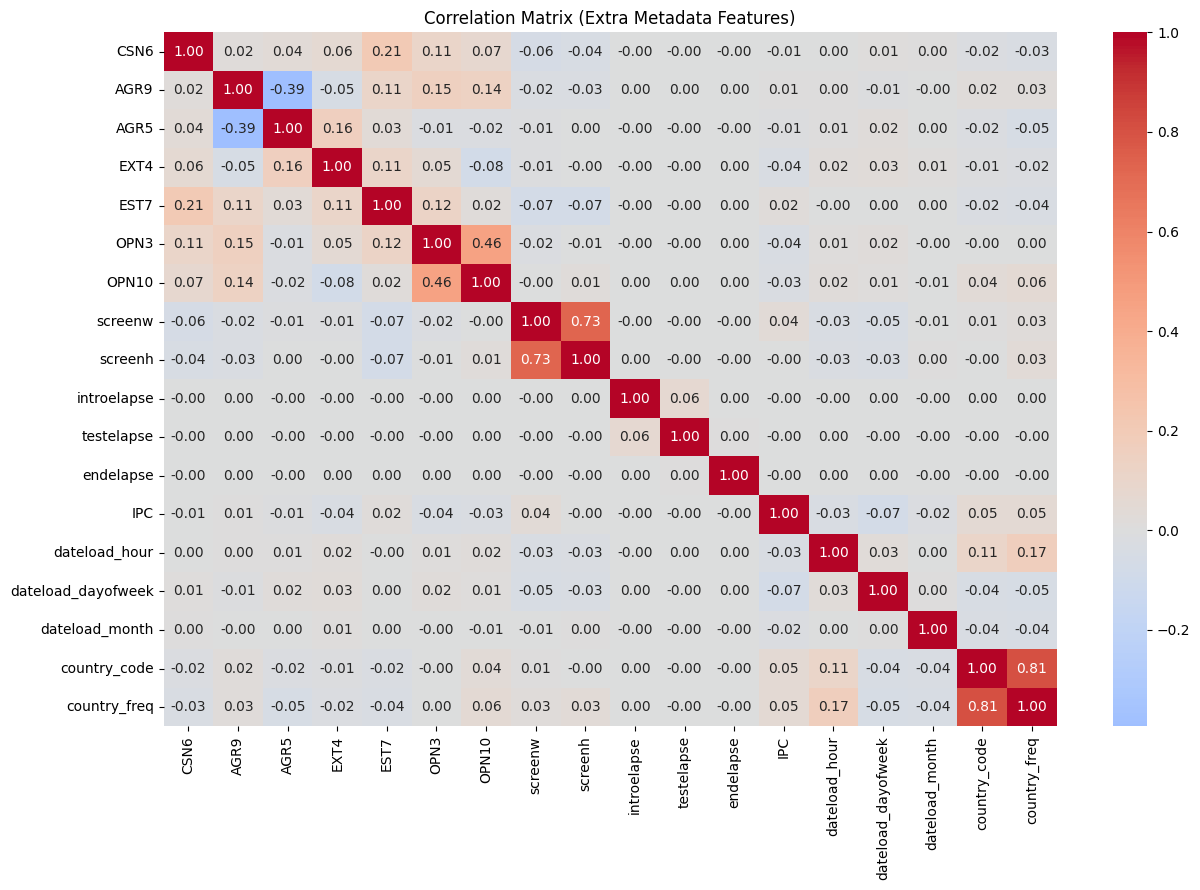

In [9]:
# Correlation Matrix for extra metadata features

extra_cols = ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10'] + [
    "dateload",
    "screenw",
    "screenh",
    "introelapse",
    "testelapse",
    "endelapse",
    "IPC",
    "country",
    "lat_appx_lots_of_err",
    "long_appx_lots_of_err",
]

extra_cols = extra_cols

extra_df = df[extra_cols].copy()

# Convert timestamp into numeric time features
extra_df["dateload"] = pd.to_datetime(extra_df["dateload"], errors="coerce")
extra_df["dateload_hour"] = extra_df["dateload"].dt.hour
extra_df["dateload_dayofweek"] = extra_df["dateload"].dt.dayofweek
extra_df["dateload_month"] = extra_df["dateload"].dt.month
extra_df = extra_df.drop(columns=["dateload"])

# Convert country to numeric proxies for correlation plotting
extra_df["country_code"] = extra_df["country"].astype("category").cat.codes
country_freq = extra_df["country"].value_counts(normalize=True)
extra_df["country_freq"] = extra_df["country"].map(country_freq)
extra_df = extra_df.drop(columns=["country"])

corr = extra_df.corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Extra Metadata Features)")
plt.tight_layout()
plt.show()

#### Summary

Now it's more interesting. It seem like `screenh` and `screenw` is so relate to personality question. I interpret that it's because each personality person type liek to use specific device. Or another word, `device screen` is correlate with `personality`. But can't decide yet. Because I don't have full inside about the different between mine and researcher environment. So I will flag it for future check now.

And I see that `country` may correlate with `personality` too, may be cause culture. But my target aim is for only one country, so I may not use it.

### Summary
for extra feature, There are so less insight to personality. Having only `Device Screen` and `Country Culture` that may worht to check in the future.

### Main Question

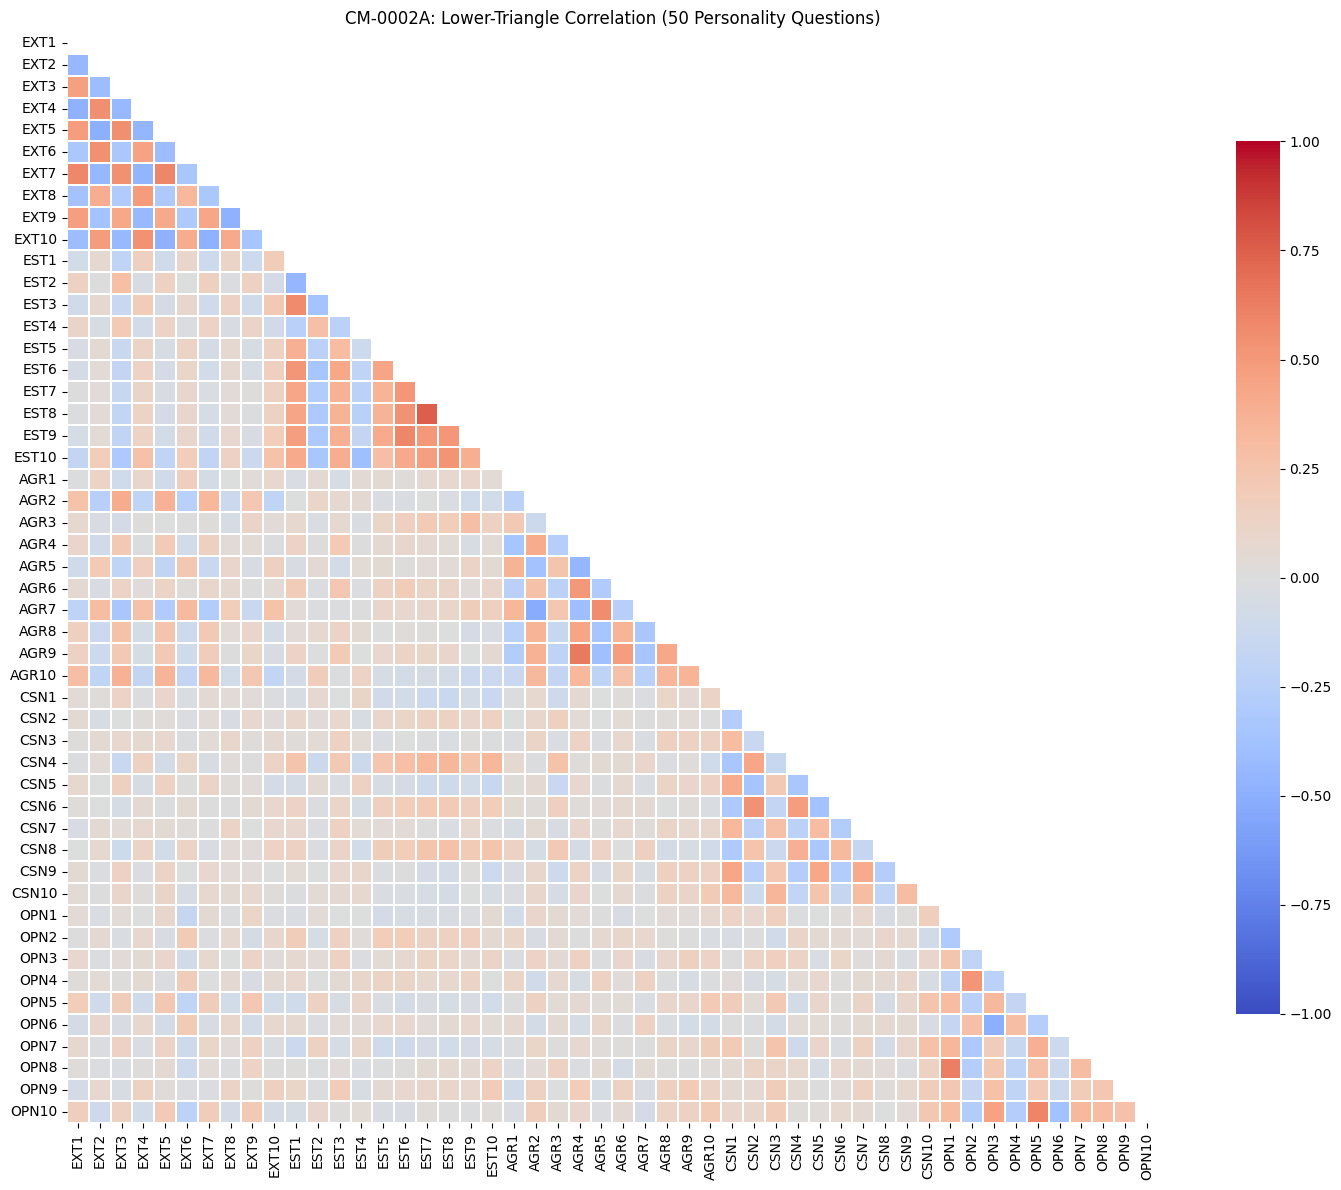

In [10]:
question_cols = [
    c for c in df.columns
    if (c[:3] in {"EXT", "EST", "AGR", "CSN", "OPN"}) and c[3:].isdigit()
]

q_corr = df[question_cols].corr(numeric_only=True)

# 1) Cleaner 50x50 view: lower-triangle heatmap (no annotations)
mask = np.triu(np.ones_like(q_corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    q_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("CM-0002A: Lower-Triangle Correlation (50 Personality Questions)")
plt.tight_layout()
plt.show()

This corr table show that the 10 question in each big personality type have the strong correlation. For example, the 10 question in the Openness type question have so strong for thierselve. With it's understandable. Mean that to make model have high precision, we can't pick all 10 question from one types out. At least we should left it for 1.

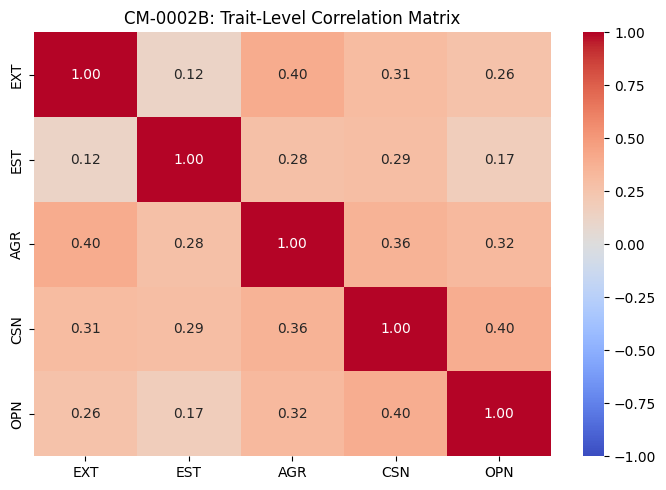

In [11]:
# 3) Compact 5x5 trait-level matrix (mean score per trait)
trait_groups = {
    "EXT": [f"EXT{i}" for i in range(1, 11)],
    "EST": [f"EST{i}" for i in range(1, 11)],
    "AGR": [f"AGR{i}" for i in range(1, 11)],
    "CSN": [f"CSN{i}" for i in range(1, 11)],
    "OPN": [f"OPN{i}" for i in range(1, 11)],
}

trait_df = pd.DataFrame({trait: df[cols].mean(axis=1) for trait, cols in trait_groups.items()})
trait_corr = trait_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(trait_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("CM-0002B: Trait-Level Correlation Matrix")
plt.tight_layout()
plt.show()

And this table show that even if between in each type of question will have strong corr. But Betweech type, it's not too wak too. Just it color have less dense than local correlation.

### Summary
1. We shouldn't pick full 10 question of each personality type, cause local correlation is super strong.
2. Between 5 big personlaity type still have strong correlation, we definitely can use it.

### Time to answer Main Question

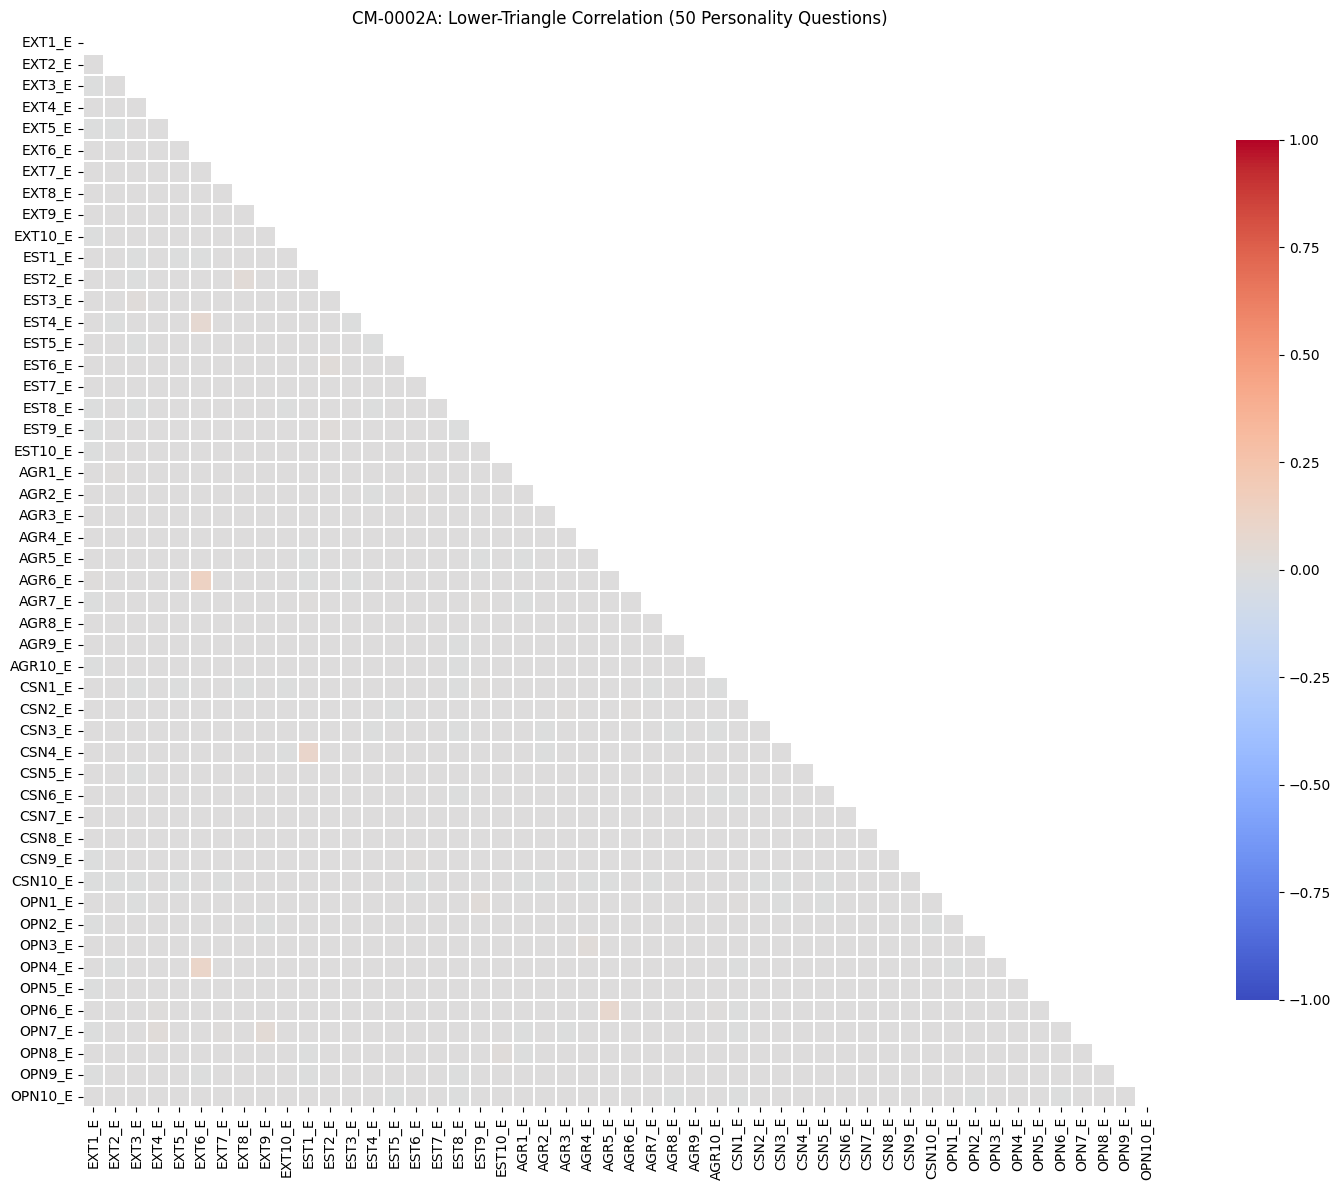

In [12]:
question_cols = [
    c for c in df.columns
    if (c[:3] in {"EXT", "EST", "AGR", "CSN", "OPN"}) and not c[3:].isdigit()
]

q_corr = df[question_cols].corr(numeric_only=True)

# 1) Cleaner 50x50 view: lower-triangle heatmap (no annotations)
mask = np.triu(np.ones_like(q_corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    q_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("CM-0002A: Lower-Triangle Correlation (50 Personality Questions)")
plt.tight_layout()
plt.show()

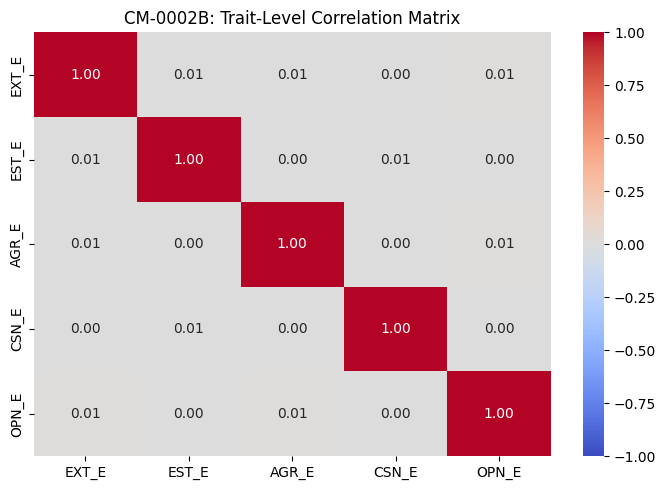

In [13]:
# 3) Compact 5x5 trait-level matrix (mean score per trait)
trait_groups = {
    "EXT_E": [f"EXT{i}_E" for i in range(1, 11)],
    "EST_E": [f"EST{i}_E" for i in range(1, 11)],
    "AGR_E": [f"AGR{i}_E" for i in range(1, 11)],
    "CSN_E": [f"CSN{i}_E" for i in range(1, 11)],
    "OPN_E": [f"OPN{i}_E" for i in range(1, 11)],
}

trait_df = pd.DataFrame({trait: df[cols].mean(axis=1) for trait, cols in trait_groups.items()})
trait_corr = trait_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(trait_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("CM-0002B: Trait-Level Correlation Matrix")
plt.tight_layout()
plt.show()

### Summary

The coorelate of time itself is so less. I think it's not worht for even use. From both researcher env different and this weak.

### Question and Timeto question correlation

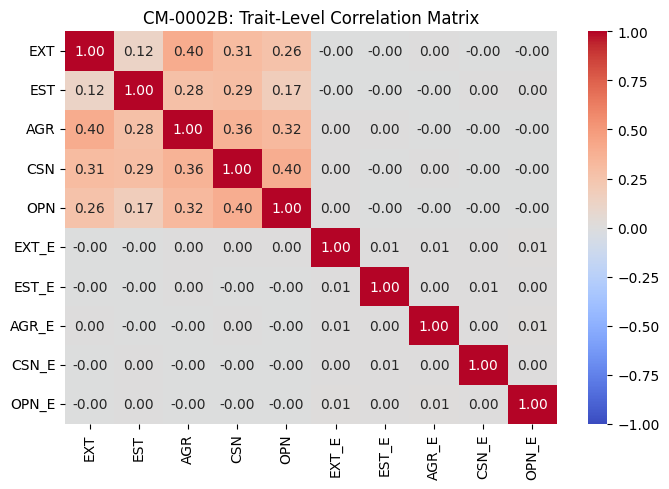

In [14]:
# 3) Compact 5x5 trait-level matrix (mean score per trait)
trait_groups = {
    "EXT": [f"EXT{i}" for i in range(1, 11)],
    "EST": [f"EST{i}" for i in range(1, 11)],
    "AGR": [f"AGR{i}" for i in range(1, 11)],
    "CSN": [f"CSN{i}" for i in range(1, 11)],
    "OPN": [f"OPN{i}" for i in range(1, 11)],
    "EXT_E": [f"EXT{i}_E" for i in range(1, 11)],
    "EST_E": [f"EST{i}_E" for i in range(1, 11)],
    "AGR_E": [f"AGR{i}_E" for i in range(1, 11)],
    "CSN_E": [f"CSN{i}_E" for i in range(1, 11)],
    "OPN_E": [f"OPN{i}_E" for i in range(1, 11)],
}

trait_df = pd.DataFrame({trait: df[cols].mean(axis=1) for trait, cols in trait_groups.items()})
trait_corr = trait_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(trait_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("CM-0002B: Trait-Level Correlation Matrix")
plt.tight_layout()
plt.show()

### Summary

There are so weak correlation, and not worth to use.

# Clean data

#### Initial

To sum up, From Data exploring, I decide to use only first 50 question, because there are super strong colleation. While other feature is have so weak, and may not worth to use now.

In [15]:
# All 50 question column names in dictionary
TRAIT_COLS = {
    "EXT": [f"EXT{i}" for i in range(1, 11)],
    "EST": [f"EST{i}" for i in range(1, 11)],
    "AGR": [f"AGR{i}" for i in range(1, 11)],
    "CSN": [f"CSN{i}" for i in range(1, 11)],
    "OPN": [f"OPN{i}" for i in range(1, 11)],
}

In [16]:
# All 50 question column in flatten list
ALL_Q_COLS = [q for trait in TRAIT_COLS.values() for q in trait]

In [17]:
# Keep only 50 question columns, drop everything else
df_clean = df[[c for c in ALL_Q_COLS if c in df.columns]].copy()
df_clean = df.copy()

#### Drop null

In [18]:
print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing amount overall: {df_clean.isnull().sum().mean()}")
print(f"Missing rate overall: {df_clean.isnull().mean().mean():.2%}")

Dataset Shape: (1015341, 110)
Missing amount overall: 1694.1636363636364
Missing rate overall: 0.17%


In [19]:
df_clean = df_clean.dropna()
df_clean.isnull().sum().sum()

np.int64(0)

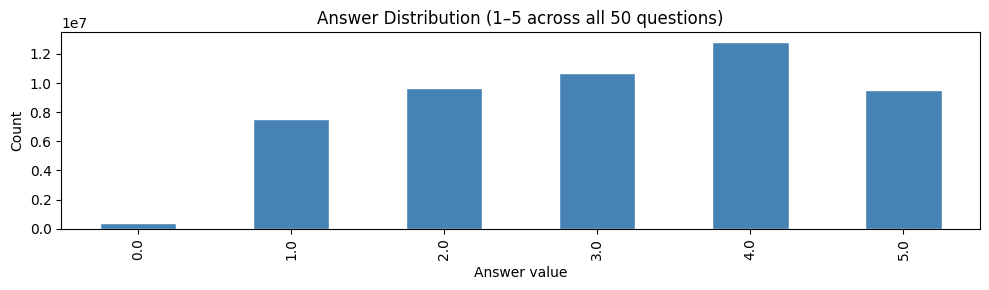

In [20]:
# Quick look at answer distribution across all questions
df_score = df_clean[ALL_Q_COLS].copy()

fig, ax = plt.subplots(figsize=(10, 3))
df_score.stack().value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Answer Distribution (1–5 across all 50 questions)")
ax.set_xlabel("Answer value")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Drop zero (missing value, same as null)

Then we still have zero value, that mean like null

In [21]:
print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing amount overall: {df_clean[ALL_Q_COLS].eq(0).any(axis=1).sum()}")
print(f"Missing rate overall: {df_clean[ALL_Q_COLS].eq(0).any(axis=1).mean():.2%}")

Dataset Shape: (1012050, 110)
Missing amount overall: 138877
Missing rate overall: 13.72%


In [22]:
# Drop rows where any question in ALL_Q_COLS equals 0 (treated as missing)
has_zero = df_clean[ALL_Q_COLS].eq(0).any(axis=1)
df_clean = df_clean.loc[~has_zero].copy()

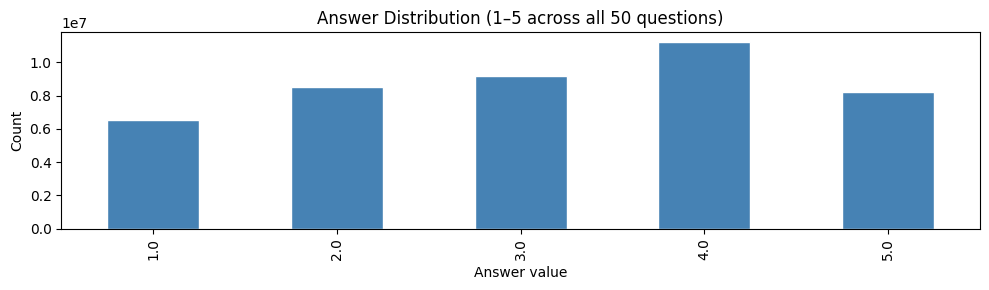

In [23]:
# Quick look at answer distribution across all questions
df_score = df_clean[ALL_Q_COLS].copy()

fig, ax = plt.subplots(figsize=(10, 3))
df_score.stack().value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Answer Distribution (1–5 across all 50 questions)")
ax.set_xlabel("Answer value")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Drop low quality data

#### 1. The IP adress for spam

I will use only use the ip that have only 1 submit, preventing the spam or etc.

In [24]:
print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing amount overall: {df_clean['IPC'].ne(1).sum()}")
print(f"Missing rate overall: {df_clean['IPC'].ne(1).mean():.2%}")

Dataset Shape: (873173, 110)
Missing amount overall: 270531
Missing rate overall: 30.98%


In [25]:
# Drop rows where IPC not equals 1 
drop = df_clean['IPC'].eq(1)
df_clean = df_clean.loc[drop].copy()
df_clean['IPC'].ne(1).sum()

np.int64(0)

#### 2. The teselapse that less than 30s or more than 30m

In [26]:
print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing amount overall: {((df_clean['testelapse']<60) | (df_clean['testelapse']>1800)).sum()}")
print(f"Missing rate overall: {((df_clean['testelapse']<60) | (df_clean['testelapse']>1800)).mean():.2%}")

Dataset Shape: (602642, 110)
Missing amount overall: 10331
Missing rate overall: 1.71%


In [27]:
# Drop rows where any question take less than 30s or more than 30m
keep = ((df_clean['testelapse']>=60) & (df_clean['testelapse']<=1800))
df_clean = df_clean.loc[keep].copy()
((df_clean['testelapse']<60) | (df_clean['testelapse']>1800)).sum()

np.int64(0)

#### 3. The question time that use less than 3 second

In [28]:
print(f"Dataset Shape: {df_clean.shape}")
print(f"Missing amount overall: {(df_clean[ALL_Q_COLS].std()<=0.3).sum()}")
print(f"Missing rate overall: {(df_clean[ALL_Q_COLS].std()<=0.3).mean():.2%}")

Dataset Shape: (592311, 110)
Missing amount overall: 0
Missing rate overall: 0.00%


### Normalize score

In [29]:
# df_clean[ALL_Q_COLS] = df_clean[ALL_Q_COLS].sub(1).div(4)

In [30]:
trait_scores = {}

for trait, questions in TRAIT_COLS.items():
    trait_df = df_clean[questions].copy()

    # Mean of answered questions per row, normalized to 0–1
    raw_mean = trait_df.mean(axis=1)        
    trait_scores[trait] = raw_mean

df_scores = pd.DataFrame(trait_scores, index=df.index)

print("Trait score stats (0–1 scale):")
df_scores.describe().round(3)

Trait score stats (0–1 scale):


,EXT,EST,AGR,CSN,OPN
count,592311.00,592311.000,592311.000,592311.000,592311.000
mean,3.03,3.048,3.167,3.143,3.310
std,0.33,0.640,0.343,0.373,0.363
min,1.00,1.000,1.000,1.000,1.000
25%,2.80,2.600,3.000,2.900,3.100
50%,3.00,3.000,3.200,3.100,3.300
75%,3.20,3.500,3.400,3.400,3.600
max,5.00,5.000,5.000,5.000,5.000


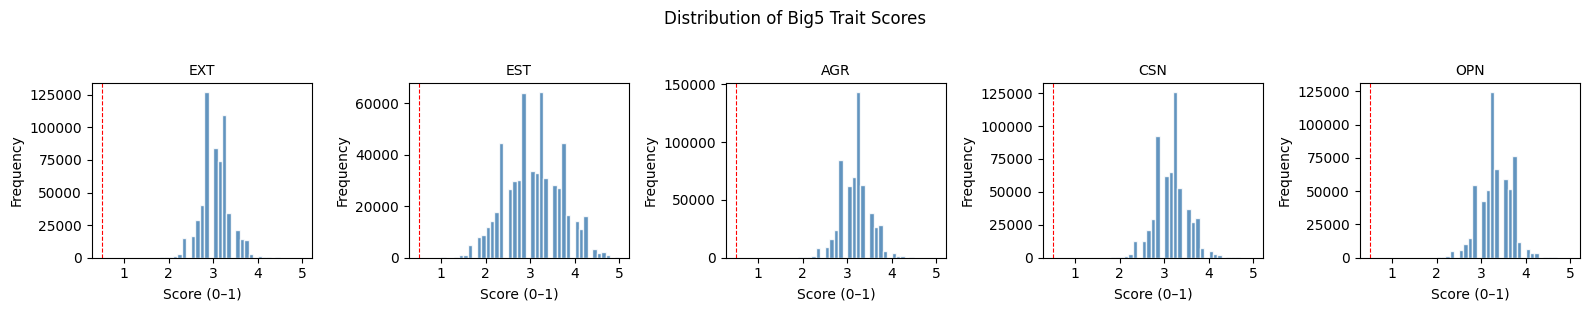

In [31]:
# Visualize trait score distributions
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=False)

expected_traits = ["EXT", "EST", "AGR", "CSN", "OPN"]
missing_traits = [t for t in expected_traits if t not in df_scores.columns]
if missing_traits:
    print(f"Warning: The following trait(s) are missing in df_scores and will be skipped: {missing_traits}")

for ax, trait in zip(axes, expected_traits):
    if trait in df_scores.columns:
        df_scores[trait].dropna().plot(kind='hist', bins=40, ax=ax,
                                       color='steelblue', edgecolor='white', alpha=0.85)
        ax.set_title(trait, fontsize=10)
        ax.set_xlabel("Score (0–1)")
        ax.axvline(0.5, color='red', linestyle='--', linewidth=0.8, label='midpoint')
    else:
        ax.set_visible(False)  # Hide axes for missing traits

plt.suptitle("Distribution of Big5 Trait Scores", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

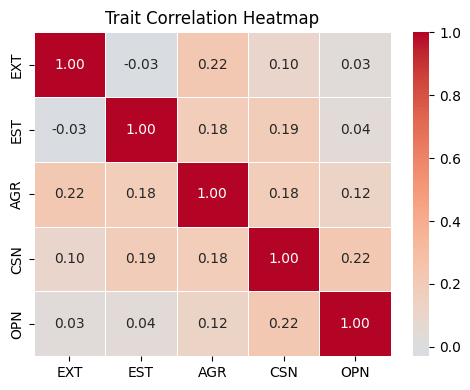

In [32]:
# Correlation heatmap between traits
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df_scores.corr().round(2), annot=True, cmap='coolwarm',
            center=0, ax=ax, fmt='.2f', linewidths=0.5)
ax.set_title("Trait Correlation Heatmap")
plt.tight_layout()
plt.show()

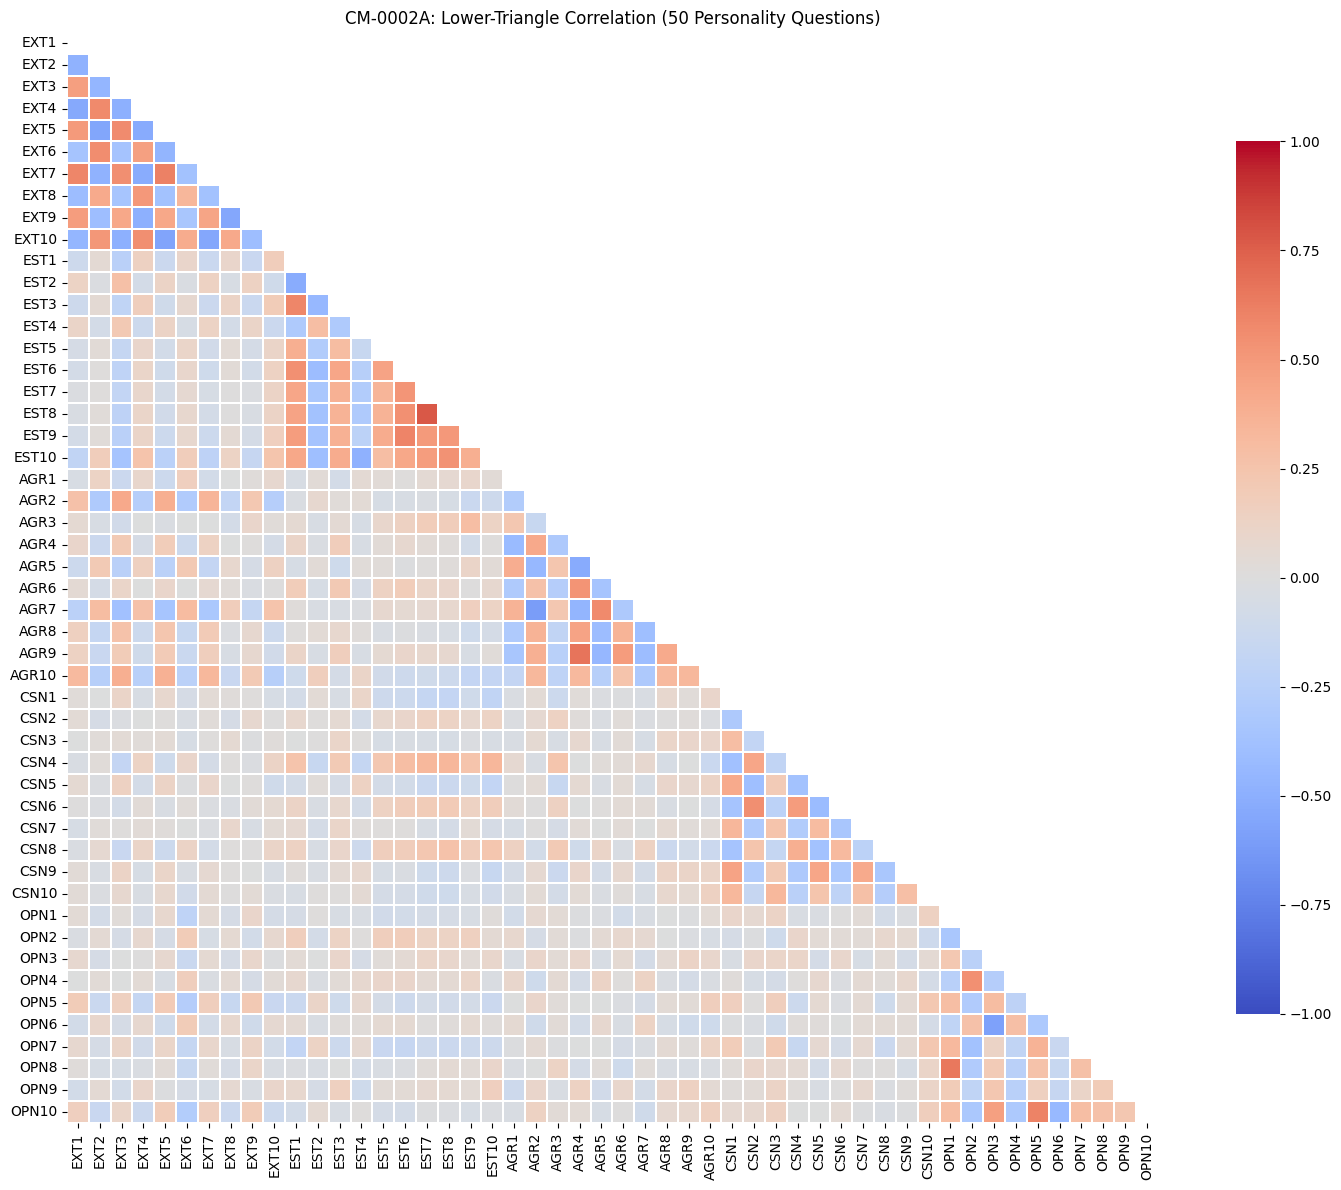

In [33]:
question_cols = [
    c for c in df.columns
    if (c[:3] in {"EXT", "EST", "AGR", "CSN", "OPN"}) and c[3:].isdigit()
]

q_corr = df_clean[question_cols].corr(numeric_only=True)

# 1) Cleaner 50x50 view: lower-triangle heatmap (no annotations)
mask = np.triu(np.ones_like(q_corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    q_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("CM-0002A: Lower-Triangle Correlation (50 Personality Questions)")
plt.tight_layout()
plt.show()

# Model And Algorithm

### Approach

The UX promises **a result at any point** between ~5 and 50 answered questions, with precision growing as the user keeps going. The result page always shows **all 50 items** (7 primary meme + 43 secondary), so for whichever subset of questions the user hasn't reached yet, the model has to fill them in.

So the model needs to:

1. Take a **variable subset** of the 50 answers as input (the rest are unknown).
2. Predict the **full 50 answers**, with extra emphasis on getting the 7 meme questions right (those are the headline).
3. Get monotonically better as more answers come in.

**Design**

- Inputs: 50 answer values (1–5; missing → 0) + a 50-bit *answered mask* → 100 features.
- Targets: the 50 original answers (matrix-completion style).
- One unified model predicts all 50; trait scores fall out as the per-trait mean, meme labels fall out by thresholding the relevant predicted item. The 7 meme items get prioritized at evaluation time so we can confirm they're the most accurate part of the output.

**Models compared**

| Model | Idea |
|---|---|
| Global Mean | Fill missing with neutral (3) |
| Trait Mean | Fill missing question Q with the mean of the user's answered questions in Q's trait |
| Ridge Regression | Linear multi-output regression on (values + mask) |

Ridge can use **cross-trait correlations** (e.g. high OPN3 → expect high OPN10), which the simple baselines cannot. We expect Ridge to beat them especially when only a few questions are answered.


In [53]:
# ML stack
import time
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Drop rows with any NaN in the 50 question columns (we saw ~0.18% missing rate)

# Meme questions that drive the 7 core personality labels (from the project vision)
MEME_QUESTIONS = ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']
MEME_IDX = [ALL_Q_COLS.index(c) for c in MEME_QUESTIONS]


### Train / Val / Test split

Split 70 / 15 / 15. The dataset is ~1M rows, so we **subsample the train fold to 100k** to keep training fast — Ridge converges fine with that many samples and 100 features.


In [54]:
SUBSAMPLE_TRAIN = 10_000_000

X_full = df_clean[ALL_Q_COLS].values.astype(np.float32)

X_temp, X_test = train_test_split(X_full, test_size=0.15, random_state=RANDOM_SEED)
X_train, X_val = train_test_split(X_temp, test_size=0.1765, random_state=RANDOM_SEED)  # 0.15 of full

if len(X_train) > SUBSAMPLE_TRAIN:
    rng_sub = np.random.default_rng(RANDOM_SEED)
    idx = rng_sub.choice(len(X_train), SUBSAMPLE_TRAIN, replace=False)
    X_train = X_train[idx]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")


Train: (414602, 50)
Val:   (88862, 50)
Test:  (88847, 50)


### Simulating partial-answer users

For training and evaluation we need to mimic what real users will do — answer only K of the 50 questions, in a random order. The function below picks a uniformly random K per row (between `k_min` and `k_max`) and a uniformly random subset of size K.


In [55]:
# Return (X_masked, mask) where mask=1 means 'answered'.
def random_mask(X: np.ndarray, k_min: int = 5, k_max: int = 50, seed: int | None = None):
    rng = np.random.default_rng(seed)
    n, q = X.shape

    # Random ranks per row (1..q). Lowest rank = "answered".
    scores = rng.random((n, q))
    ranks = np.argsort(np.argsort(scores, axis=1), axis=1) + 1  # 1..q

    ks = rng.integers(k_min, k_max + 1, size=n).reshape(-1, 1)
    mask = (ranks <= ks).astype(np.float32)

    return X * mask, mask


# Quick sanity check
_xm, _m = random_mask(X_train[:5], k_min=5, k_max=50, seed=0)
print(f"Per-row K (first 5 rows): {_m.sum(axis=1).astype(int).tolist()}")

Per-row K (first 5 rows): [8, 22, 28, 19, 36]


### Baselines

Two cheap heuristics to beat:

1. **Global mean** — fill every missing answer with `3` (neutral).
2. **Trait mean** — fill missing question `Q` with the mean of the *answered* questions in the same trait. This is essentially what `df_scores` already does for trait scores and is a strong baseline.

If Ridge can't beat *Trait Mean*, it's not worth deploying.


In [56]:
COL_TO_IDX = {c: i for i, c in enumerate(ALL_Q_COLS)}
TRAIT_IDXS = {trait: np.array([COL_TO_IDX[c] for c in qs]) for trait, qs in TRAIT_COLS.items()}


def predict_global_mean(X_masked: np.ndarray, mask: np.ndarray) -> np.ndarray:
    pred = X_masked.copy()
    pred[mask == 0] = 3.0
    return pred


def predict_trait_mean(X_masked: np.ndarray, mask: np.ndarray) -> np.ndarray:
    pred = X_masked.copy()
    for trait, idxs in TRAIT_IDXS.items():
        sub_x = X_masked[:, idxs]
        sub_m = mask[:, idxs]
        n_ans = sub_m.sum(axis=1)
        sum_ans = sub_x.sum(axis=1)
        # Mean of answered for this trait; fall back to 3 if zero answered in trait
        trait_mean = np.where(n_ans > 0, sum_ans / np.maximum(n_ans, 1), 3.0)

        unanswered = sub_m == 0
        # Broadcast trait_mean over the trait's columns
        pred[:, idxs] = np.where(unanswered, trait_mean[:, None], sub_x)
    return pred


### Ridge regression with masking

Train a single multi-output `Ridge` to predict all 50 answers from `[masked_values | mask]`.

We pick `alpha` by trying a few values on the validation set (using the average MAE across K=5,10,20,30,50 missing entries).


In [57]:
def make_features(X_masked: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Stack [values, mask] -> 100 features."""
    return np.hstack([X_masked, mask]).astype(np.float32)


# Build training matrix once
Xtr_masked, Mtr = random_mask(X_train, k_min=5, k_max=50, seed=RANDOM_SEED)
Xtr_feats = make_features(Xtr_masked, Mtr)
Ytr = X_train  # predict the full 50 answers


def ridge_validation_mae(alpha: float, x_val: np.ndarray) -> float:
    model = Ridge(alpha=alpha)
    t0 = time.time()
    model.fit(Xtr_feats, Ytr)
    fit_time = time.time() - t0

    maes = []
    for k in (5, 10, 20, 30, 40, 50):
        Xv_masked, Mv = random_mask(x_val, k_min=k, k_max=k, seed=k)
        pred = model.predict(make_features(Xv_masked, Mv))
        pred = np.where(Mv == 1, Xv_masked, pred)  # don't overwrite answered
        pred = np.clip(pred, 1, 5)
        missing = Mv == 0
        if missing.any():
            maes.append(np.abs(pred[missing] - x_val[missing]).mean())
    return float(np.mean(maes)), fit_time, model


alphas = [0.1, 1.0, 10.0, 100.0, 200, 400, 800, 1600]
val_results = []
ridge_models = {}
for a in alphas:
    mae, ft, m = ridge_validation_mae(a, X_val)
    val_results.append({"alpha": a, "val_mae": mae, "fit_s": round(ft, 2)})
    ridge_models[a] = m
val_df = pd.DataFrame(val_results)
print(val_df.to_string(index=False))

best_alpha = val_df.loc[val_df["val_mae"].idxmin(), "alpha"]
ridge = ridge_models[best_alpha]
print(f"\nBest alpha: {best_alpha}")


 alpha  val_mae  fit_s
   0.1 0.882824   0.36
   1.0 0.882822   0.30
  10.0 0.882801   0.29
 100.0 0.882593   0.29
 200.0 0.882369   0.30
 400.0 0.881943   0.32
 800.0 0.881174   0.40
1600.0 0.879916   0.32

Best alpha: 1600.0


### Evaluation: precision vs. number of questions answered

For each model and each K in {5, 10, 13, 20, 30, 40, 50}:
- mask each test user down to K random answers,
- predict the missing answers,
- report MAE on the missing answers, MAE on the 5 trait scores (0–1), and MAE on the 7 meme question scores.

We average over 3 random seeds to smooth noise.


In [58]:
def predict_ridge(X_masked: np.ndarray, mask: np.ndarray) -> np.ndarray:
    pred = ridge.predict(make_features(X_masked, mask))
    pred = np.where(mask == 1, X_masked, pred)
    return np.clip(pred, 1, 5)


def trait_scores_from_answers(X: np.ndarray) -> np.ndarray:
    """Convert (n, 50) answers into (n, 5) trait scores (1..5 scale)."""
    out = np.empty((len(X), len(TRAIT_IDXS)), dtype=np.float32)
    for ti, idxs in enumerate(TRAIT_IDXS.values()):
        out[:, ti] = X[:, idxs].mean(axis=1)
    return out


# Evaluate on the full test set, reusing each row across MANY random masks per K.
# More mask reuse  ->  tighter variance estimates  ->  meaningful confidence bands.
N_EVAL_SEEDS = 10

def evaluate_model(name: str, predict_fn, X_eval: np.ndarray,
                   k_values=(5, 10, 15, 20, 25, 30, 35, 40, 43, 49),
                   n_seeds: int = N_EVAL_SEEDS) -> pd.DataFrame:
    rows = []
    true_traits = trait_scores_from_answers(X_eval)
    for k in k_values:
        mae_q_seeds, mae_t_seeds, mae_meme_seeds = [], [], []
        for s in range(n_seeds):
            Xm, M = random_mask(X_eval, k_min=k, k_max=k, seed=1000 + s)
            pred = predict_fn(Xm, M)

            missing = M == 0  # shape (n, 50), True where answer was hidden

            # --- Per-answer MAE on missing positions only (unchanged) ---
            if missing.any():
                mae_q_seeds.append(np.abs(pred[missing] - X_eval[missing]).mean())

            # --- Trait MAE: only over traits where ALL questions were missing ---
            # For a fairer but more lenient metric, use traits with ANY missing question.
            # Here we use per-question missing to compute trait-level error only on
            # the missing portion of each trait's questions.
            trait_maes = []
            for ti, idxs in enumerate(TRAIT_IDXS.values()):
                trait_missing = missing[:, idxs]  # (n, n_questions_in_trait)
                if not trait_missing.any():
                    continue
                # Only score predictions on the missing cells within this trait
                pred_vals = pred[:, idxs][trait_missing]
                true_vals = X_eval[:, idxs][trait_missing]
                trait_maes.append(np.abs(pred_vals - true_vals).mean())
            if trait_maes:
                mae_t_seeds.append(float(np.mean(trait_maes)))

            # A row's meme questions are "missing" if ANY of the meme questions were masked
            meme_missing_rows = missing[:, MEME_IDX].any(axis=1)  # (n,) boolean

            if meme_missing_rows.any():
                # Only evaluate on the meme question cells that were actually missing
                meme_missing_cells = missing[:, MEME_IDX]  # (n, 7)
                pred_meme = pred[:, MEME_IDX][meme_missing_rows]      # (n_rows, 7)
                true_meme = X_eval[:, MEME_IDX][meme_missing_rows]    # (n_rows, 7)
                cell_mask = meme_missing_cells[meme_missing_rows]      # (n_rows, 7)

                mae_meme_seeds.append(
                    np.abs(pred_meme[cell_mask] - true_meme[cell_mask]).mean()
                )

        rows.append({
            "model": name, "k": k,
            "mae_missing_answer":      float(np.mean(mae_q_seeds))     if mae_q_seeds else 0.0,
            "mae_missing_answer_std":  float(np.std(mae_q_seeds))      if mae_q_seeds else 0.0,
            "mae_trait_score":         float(np.mean(mae_t_seeds))      if mae_t_seeds else 0.0,
            "mae_trait_score_std":     float(np.std(mae_t_seeds))       if mae_t_seeds else 0.0,
            "mae_meme_answer":         float(np.mean(mae_meme_seeds))   if mae_meme_seeds else 0.0,
            "mae_meme_answer_std":     float(np.std(mae_meme_seeds))    if mae_meme_seeds else 0.0,
        })
    return pd.DataFrame(rows)


X_test_eval = X_test[:]

results = pd.concat([
    evaluate_model("Global Mean", predict_global_mean, X_test_eval),
    evaluate_model("Trait Mean",  predict_trait_mean,  X_test_eval),
    evaluate_model(f"Ridge (a={best_alpha})", predict_ridge, X_test_eval),
], ignore_index=True)

print(f"Each row averaged over {N_EVAL_SEEDS} different random subsets per user.\n")
print("Trait-score MAE (lower = better) by K:")
print(results.pivot(index="k", columns="model", values="mae_trait_score").round(4))


Each row averaged over 10 different random subsets per user.

Trait-score MAE (lower = better) by K:
model  Global Mean  Ridge (a=1600.0)  Trait Mean
k                                               
5           1.1290            0.9526      1.2884
10          1.1290            0.9292      1.2986
15          1.1290            0.9064      1.2692
20          1.1290            0.8839      1.2387
25          1.1290            0.8621      1.2166
30          1.1289            0.8407      1.2018
35          1.1291            0.8200      1.1920
40          1.1290            0.7998      1.1849
43          1.1290            0.7880      1.1816
49          1.1294            0.7653      1.1757


### Visualizing precision growth

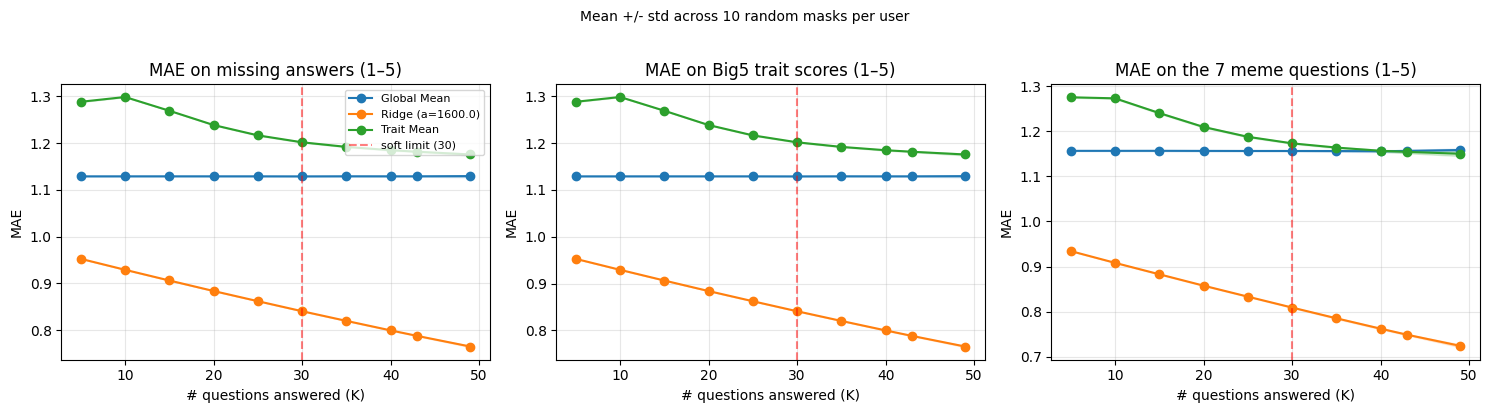

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

metric_titles = [
    ("mae_missing_answer", "MAE on missing answers (1–5)"),
    ("mae_trait_score",    "MAE on Big5 trait scores (1–5)"),
    ("mae_meme_answer",    "MAE on the 7 meme questions (1–5)"),
]
for ax, (metric, title) in zip(axes, metric_titles):
    for name, group in results.groupby("model"):
        ks = group["k"].values
        mu = group[metric].values
        sd = group[metric + "_std"].values
        line, = ax.plot(ks, mu, marker="o", label=name)
        ax.fill_between(ks, mu - sd, mu + sd, alpha=0.18, color=line.get_color())
    ax.set_xlabel("# questions answered (K)")
    ax.set_ylabel("MAE")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.axvline(30, color="red", linestyle="--", alpha=0.5, label="soft limit (30)")
axes[0].legend(loc="upper right", fontsize=8)
plt.suptitle(f"Mean +/- std across {N_EVAL_SEEDS} random masks per user", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


### Per-question and per-trait breakdown

Where does the model's error actually come from? With many random masks per user we
can compute the MAE separately for each of the 50 questions (only counting cases where
that question was masked-out, of course) and for each of the 5 traits. This tells us:

- **Which of the 50 questions are inherently easy / hard to predict.** Items strongly
  correlated with the rest of their trait are easy; quirky items are hard.
- **Whether the 7 meme questions are at the easy or hard end** — they're the headline,
  so we want them to be on the easier side.
- **Which traits the model is most confident on.** Some traits have more redundancy
  than others, which directly maps to lower MAE.


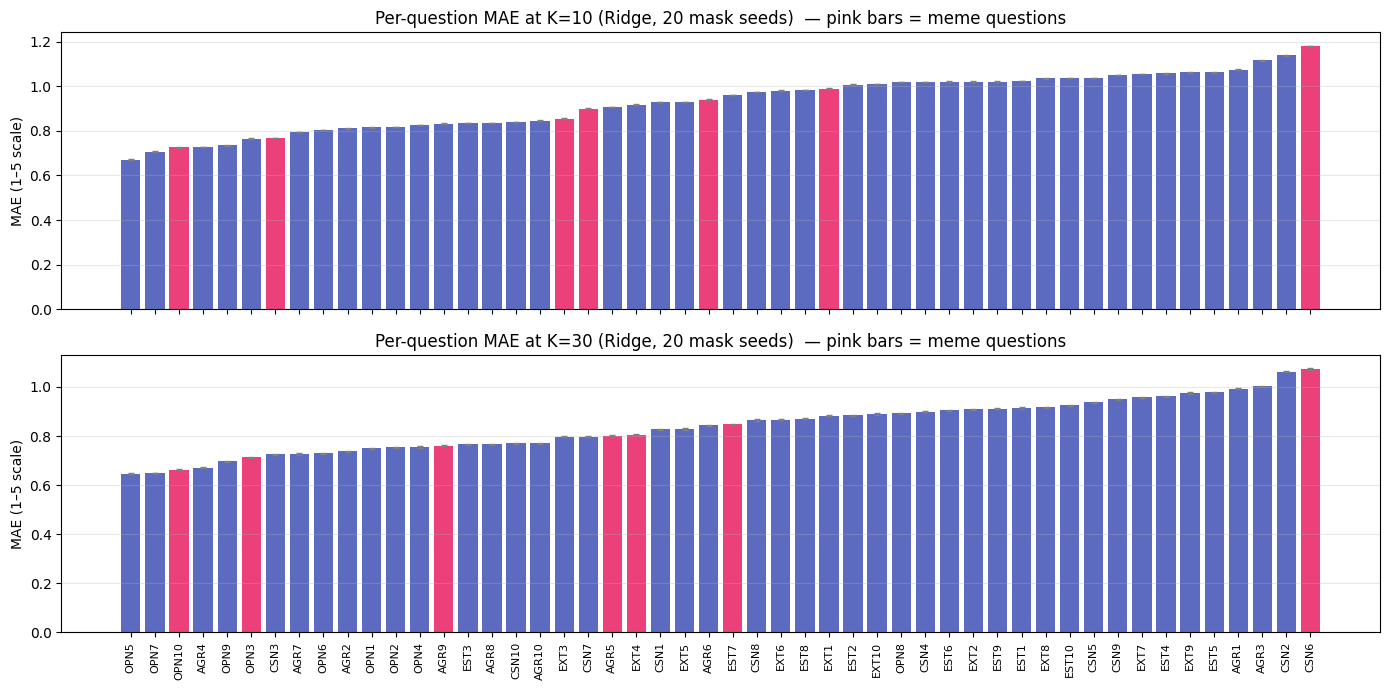


Meme-question ranking by MAE at K=30 (1 = easiest, 50 = hardest):
  CSN6    rank 50/50   MAE = 1.073
  AGR9    rank 14/50   MAE = 0.760
  AGR5    rank 21/50   MAE = 0.802
  EXT4    rank 22/50   MAE = 0.806
  EST7    rank 26/50   MAE = 0.848
  OPN3    rank  6/50   MAE = 0.713
  OPN10   rank  3/50   MAE = 0.663


In [60]:
# Per-question MAE for Ridge across many mask seeds.
# Mask each test user with a random K, predict, then bucket squared/abs errors by question.
N_PQ_SEEDS = 20
K_FOR_PQ = (10, 30)   # show two snapshots: low-K (user just started) vs at the soft limit

fig, axes = plt.subplots(len(K_FOR_PQ), 1, figsize=(14, 7), sharex=True)
if len(K_FOR_PQ) == 1:
    axes = [axes]

for ax, k_pq in zip(axes, K_FOR_PQ):
    per_q_errs = [[] for _ in range(50)]
    for s in range(N_PQ_SEEDS):
        Xm, M = random_mask(X_test_eval, k_min=k_pq, k_max=k_pq, seed=2000 + s)
        pred = predict_ridge(Xm, M)
        missing = M == 0
        # vectorised per-question MAE on missing entries only
        abs_err = np.abs(pred - X_test_eval) * missing
        n_miss  = missing.sum(axis=0)              # (50,) — how many users had Q masked
        sum_err = abs_err.sum(axis=0)              # (50,) — sum of |pred - true|
        for q in range(50):
            if n_miss[q] > 0:
                per_q_errs[q].append(sum_err[q] / n_miss[q])

    means = np.array([np.mean(e) if e else np.nan for e in per_q_errs])
    stds  = np.array([np.std(e)  if e else 0.0    for e in per_q_errs])

    # Sort questions ascending by MAE for readability
    order = np.argsort(means)
    sorted_qs    = [ALL_Q_COLS[i] for i in order]
    sorted_means = means[order]
    sorted_stds  = stds[order]
    colors = ["#e91e63" if ALL_Q_COLS[i] in MEME_QUESTIONS else "#3f51b5" for i in order]

    ax.bar(range(50), sorted_means, yerr=sorted_stds, color=colors, alpha=0.85,
           error_kw=dict(ecolor="gray", lw=0.8, capsize=2))
    ax.set_xticks(range(50))
    ax.set_xticklabels(sorted_qs, rotation=90, fontsize=8)
    ax.set_ylabel("MAE (1–5 scale)")
    ax.set_title(f"Per-question MAE at K={k_pq} (Ridge, {N_PQ_SEEDS} mask seeds)  "
                 f"— pink bars = meme questions")
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Summary: where do the meme questions land in the ranking?
last_means = means          # from the last K_FOR_PQ entry (K = K_FOR_PQ[-1])
order = np.argsort(last_means)
ranks = {ALL_Q_COLS[order[i]]: i + 1 for i in range(50)}
print(f"\nMeme-question ranking by MAE at K={K_FOR_PQ[-1]} (1 = easiest, 50 = hardest):")
for q in MEME_QUESTIONS:
    print(f"  {q:<6}  rank {ranks[q]:>2}/50   MAE = {last_means[ALL_Q_COLS.index(q)]:.3f}")


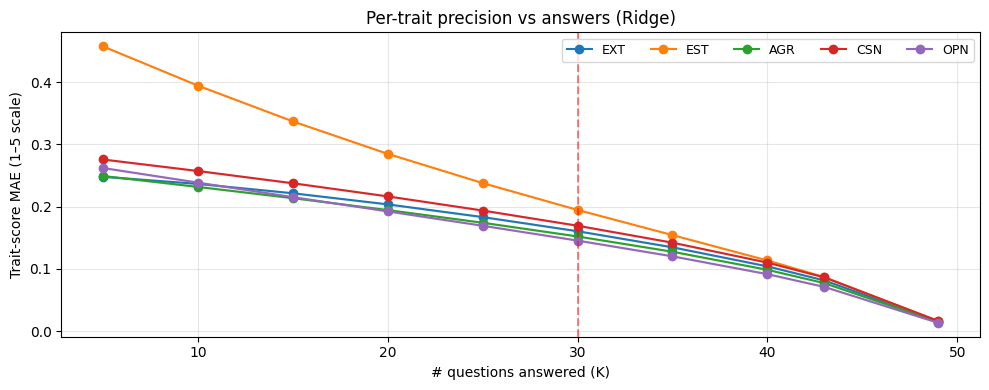

Per-trait MAE (1–5 scale):
         EXT     EST     AGR     CSN     OPN
K=5   0.2480  0.4574  0.2493  0.2758  0.2621
K=10  0.2366  0.3944  0.2318  0.2573  0.2387
K=15  0.2216  0.3370  0.2137  0.2377  0.2154
K=20  0.2038  0.2849  0.1946  0.2166  0.1925
K=25  0.1834  0.2380  0.1742  0.1939  0.1694
K=30  0.1607  0.1948  0.1522  0.1695  0.1456
K=35  0.1348  0.1544  0.1277  0.1423  0.1203
K=40  0.1042  0.1137  0.0987  0.1102  0.0917
K=43  0.0816  0.0869  0.0773  0.0864  0.0712
K=49  0.0156  0.0160  0.0148  0.0166  0.0135


In [61]:
# Per-trait MAE across the same K sweep, again averaged over many mask seeds.
TRAIT_NAMES = list(TRAIT_IDXS.keys())   # ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
K_VALUES_PT = (5, 10, 15, 20, 25, 30, 35, 40, 43, 49)

per_trait_mean = np.zeros((len(K_VALUES_PT), len(TRAIT_NAMES)))
per_trait_std  = np.zeros((len(K_VALUES_PT), len(TRAIT_NAMES)))

for ki, k in enumerate(K_VALUES_PT):
    seeds_per_trait = [[] for _ in TRAIT_NAMES]
    for s in range(N_EVAL_SEEDS):
        Xm, M = random_mask(X_test_eval, k_min=k, k_max=k, seed=3000 + s)
        pred = predict_ridge(Xm, M)
        for ti, idxs in enumerate(TRAIT_IDXS.values()):
            true_t = X_test_eval[:, idxs].mean(axis=1)
            pred_t = pred[:, idxs].mean(axis=1)
            seeds_per_trait[ti].append(np.abs(pred_t - true_t).mean())
    for ti in range(len(TRAIT_NAMES)):
        per_trait_mean[ki, ti] = np.mean(seeds_per_trait[ti])
        per_trait_std[ki, ti]  = np.std(seeds_per_trait[ti])

fig, ax = plt.subplots(figsize=(10, 4))
for ti, trait in enumerate(TRAIT_NAMES):
    line, = ax.plot(K_VALUES_PT, per_trait_mean[:, ti], marker="o", label=trait)
    ax.fill_between(K_VALUES_PT,
                    per_trait_mean[:, ti] - per_trait_std[:, ti],
                    per_trait_mean[:, ti] + per_trait_std[:, ti],
                    alpha=0.15, color=line.get_color())
ax.set_xlabel("# questions answered (K)")
ax.set_ylabel("Trait-score MAE (1–5 scale)")
ax.set_title("Per-trait precision vs answers (Ridge)")
ax.axvline(30, color="red", linestyle="--", alpha=0.5)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=5)
plt.tight_layout()
plt.show()

# Print the table form
print("Per-trait MAE (1–5 scale):")
print(pd.DataFrame(per_trait_mean.round(4),
                   index=[f"K={k}" for k in K_VALUES_PT],
                   columns=TRAIT_NAMES).to_string())


### Result

- **Ridge** wins across every K — its biggest advantage is at low K (the user has answered very few questions) where it can lean on cross-trait correlations.
- All models converge as K → 50 (when everything is answered, predictions don't matter for the missing entries).
- The middle plot (trait-score MAE) is what powers the **precision bar** in the UI. It drops sharply over the first ~13 answers and flattens by 30 — that's the empirical reason for the **soft "you can stop here" prompt at 30**.
- The right plot (meme-question MAE) is the one we care about most, since the 7 meme items are the headline of every result page. Ridge keeps it noticeably lower than the baselines at every K.

Pick **Ridge** as the production model.


### Persist the chosen model

We bundle everything the quiz app needs to call the model at inference time: the trained Ridge, the column order, and the meme-question indices.


In [43]:
artifact = {
    "ridge": ridge,
    "alpha": float(best_alpha),
    "all_q_cols": ALL_Q_COLS,
    "trait_cols": TRAIT_COLS,
    "meme_questions": MEME_QUESTIONS,
}

out_path = Path("./artifacts").resolve()
out_path.mkdir(exist_ok=True)
joblib.dump(artifact, out_path / "big5_ridge.joblib")
print(f"Saved model bundle to {out_path / 'big5_ridge.joblib'}")


def predict_personality(answers: dict[str, float]) -> dict:
    """Convenience function for the quiz front-end.

    Takes whatever subset of the 50 questions the user has answered so far
    ({question_code: 1..5}) and returns the full result page payload:

    - `trait_scores`: 5 Big5 trait scores in 0..1 (drives the precision bar)
    - `primary`:   the 7 meme questions, split into `answered` (known) vs `predicted`
    - `secondary`: the other 43 questions, same split
    - `n_answered`: how many of the 50 the user has answered

    Always returns predictions for all 50 items regardless of how many were
    answered, so the result page can render the same layout for every K.
    """
    x = np.zeros((1, len(ALL_Q_COLS)), dtype=np.float32)
    m = np.zeros((1, len(ALL_Q_COLS)), dtype=np.float32)
    for q, v in answers.items():
        if q in COL_TO_IDX:
            x[0, COL_TO_IDX[q]] = float(v)
            m[0, COL_TO_IDX[q]] = 1.0

    pred = predict_ridge(x, m)[0]
    traits = trait_scores_from_answers(pred[None, :])[0]
    answered_set = set(answers)

    def split(q_codes):
        ans, prd = {}, {}
        for q in q_codes:
            v = round(float(pred[COL_TO_IDX[q]]), 2)
            (ans if q in answered_set else prd)[q] = v
        return {"answered": ans, "predicted": prd}

    secondary_qs = [q for q in ALL_Q_COLS if q not in MEME_QUESTIONS]

    return {
        "n_answered": int(m.sum()),
        "trait_scores": dict(zip(TRAIT_COLS.keys(), traits.round(3).tolist())),
        "primary":   split(MEME_QUESTIONS),
        "secondary": split(secondary_qs),
    }


# Smoke test: 5 answers (incl. one meme question, CSN6). Should return all 50 items
# split as 5 known + 45 predicted.
demo = {"EXT3": 4, "EXT2": 2, "OPN3": 3, "CSN6": 1, "AGR2": 4}

result = predict_personality(demo)
print(f"answered: {result['n_answered']}")
print(f"primary   -> known: {len(result['primary']['answered'])}, predicted: {len(result['primary']['predicted'])}")
print(f"secondary -> known: {len(result['secondary']['answered'])}, predicted: {len(result['secondary']['predicted'])}")
result


Saved model bundle to C:\Users\BTCOM\Desktop\1_Uni\B5Personality\models\artifacts\big5_ridge.joblib
answered: 5
primary   -> known: 2, predicted: 5
secondary -> known: 3, predicted: 40


{'n_answered': 5,
 'trait_scores': {'EXT': 3.010999917984009,
  'EST': 3.013000011444092,
  'AGR': 3.1630001068115234,
  'CSN': 2.937000036239624,
  'OPN': 3.190000057220459},
 'primary': {'answered': {'CSN6': 1.0, 'OPN3': 3.0},
  'predicted': {'AGR9': 3.79,
   'AGR5': 2.26,
   'EXT4': 3.06,
   'EST7': 3.02,
   'OPN10': 3.86}},
 'secondary': {'answered': {'EXT2': 2.0, 'EXT3': 4.0, 'AGR2': 4.0},
  'predicted': {'EXT1': 2.65,
   'EXT5': 3.39,
   'EXT6': 2.3,
   'EXT7': 2.81,
   'EXT8': 3.41,
   'EXT9': 3.01,
   'EXT10': 3.48,
   'EST1': 3.3,
   'EST2': 3.17,
   'EST3': 3.83,
   'EST4': 2.65,
   'EST5': 2.82,
   'EST6': 2.82,
   'EST8': 2.66,
   'EST9': 3.08,
   'EST10': 2.79,
   'AGR1': 2.19,
   'AGR3': 2.26,
   'AGR4': 3.95,
   'AGR6': 3.72,
   'AGR7': 2.13,
   'AGR8': 3.71,
   'AGR10': 3.62,
   'CSN1': 3.38,
   'CSN2': 2.73,
   'CSN3': 4.02,
   'CSN4': 2.46,
   'CSN5': 2.69,
   'CSN7': 3.82,
   'CSN8': 2.42,
   'CSN9': 3.22,
   'CSN10': 3.63,
   'OPN1': 3.75,
   'OPN2': 2.03,
   'OPN4'

# Test

Just to make sure that no data leakage in main model

In [44]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings

In [45]:
MEME_QUESTIONS = ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']

In [46]:
X = df_clean[[x for x in ALL_Q_COLS if x not in MEME_QUESTIONS]]
y = df_clean[[x for x in ALL_Q_COLS if x in MEME_QUESTIONS]]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: X={X_train.shape}, y={y_train.shape}')
print(f'Test  set: X={X_test.shape},  y={y_test.shape}')

Train set: X=(473848, 43), y=(473848, 7)
Test  set: X=(118463, 43),  y=(118463, 7)


In [48]:
# XGBoost Hyperparameters
XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='mae',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

models = {}
results = {}

for target in MEME_QUESTIONS:
    print(f'Training XGBoost for: {target} ...', end=' ')
    
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_test, y_test[target])],
        verbose=False
    )
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train[target], y_pred_train)
    mae_test  = mean_absolute_error(y_test[target],  y_pred_test)
    
    models[target] = model
    results[target] = {
        'MAE_train': mae_train,
        'MAE_test':  mae_test,
        'y_pred_test': y_pred_test
    }
    print(f'  Train MAE={mae_train:.4f}  |  Test MAE={mae_test:.4f}')

print('\nAll models trained successfully.')

Training XGBoost for: CSN6 ...   Train MAE=0.8106  |  Test MAE=0.8185
Training XGBoost for: AGR9 ...   Train MAE=0.5744  |  Test MAE=0.5805
Training XGBoost for: AGR5 ...   Train MAE=0.6255  |  Test MAE=0.6347
Training XGBoost for: EXT4 ...   Train MAE=0.6066  |  Test MAE=0.6118
Training XGBoost for: EST7 ...   Train MAE=0.5670  |  Test MAE=0.5716
Training XGBoost for: OPN3 ...   Train MAE=0.5382  |  Test MAE=0.5451
Training XGBoost for: OPN10 ...   Train MAE=0.5094  |  Test MAE=0.5157

All models trained successfully.


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

RIDGE_ALPHA = 20

models = {}
results = {}

for target in MEME_QUESTIONS:
    print(f"Training Ridge for: {target} ...", end=" ")

    model = Pipeline(
        [
            ("ridge", Ridge(alpha=RIDGE_ALPHA, random_state=42)),
        ]
    )
    model.fit(X_train, y_train[target])

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    mae_train = mean_absolute_error(y_train[target], y_pred_train)
    mae_test = mean_absolute_error(y_test[target], y_pred_test)

    models[target] = model
    results[target] = {
        "MAE_train": mae_train,
        "MAE_test": mae_test,
        "y_pred_test": y_pred_test,
    }
    print(f"  Train MAE={mae_train:.4f}  |  Test MAE={mae_test:.4f}")

print("\nAll models trained successfully.")

Training Ridge for: CSN6 ...   Train MAE=0.8291  |  Test MAE=0.8284
Training Ridge for: AGR9 ...   Train MAE=0.5922  |  Test MAE=0.5914
Training Ridge for: AGR5 ...   Train MAE=0.6432  |  Test MAE=0.6457
Training Ridge for: EXT4 ...   Train MAE=0.6279  |  Test MAE=0.6271
Training Ridge for: EST7 ...   Train MAE=0.5891  |  Test MAE=0.5880
Training Ridge for: OPN3 ...   Train MAE=0.5863  |  Test MAE=0.5864
Training Ridge for: OPN10 ...   Train MAE=0.5345  |  Test MAE=0.5349

All models trained successfully.
